# PINN para Caso: Pitzdaily - Prova de Conceito Metodológica

O caso pitzDaily será utilizado inicialmente como ambiente controlado para desenvolvimento e validação do pipeline computacional, por já estar disponível na biblioteca de tutoriais do OpenFOAM e permitir rápida geração de dados coarse/fine.

Após a validação metodológica, o pipeline será transferido para um caso BFS benchmark com parâmetros compatíveis com dados DNS disponíveis na literatura. Nessa segunda etapa, o DNS será utilizado exclusivamente como referência externa de validação, não como fonte de treinamento.

In [24]:
# Inicializa as bibliotecas necessárias
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_CFD = PATH_DIR / 'cfd_bfs'
PATH_DATA = PATH_DIR / 'data'
PATH_OUT = PATH_DIR / 'results'
PATH_MODEL = PATH_OUT / 'model'
print(PATH_DIR)
print(PATH_CFD)
print(PATH_DATA)
print(PATH_OUT)
print(PATH_MODEL)

/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_pitzDaily
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_pitzDaily/cfd_bfs
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_pitzDaily/data
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_pitzDaily/results
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_pitzDaily/results/model


## Preparando Dataset dos dados CFD
- Aqui preparamos o dataset que será utilizado no treinamento da PINN, com a diferença entre a malha coarse(grosseira) e a fine(refinada), para que assim a rede aprenda justamente a correção delta.

In [25]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def read_grid_file(path: Path) -> pd.DataFrame:
    """
    Lê o arquivo grid2D_p_U.xy no formato:
    x y z epsilon k nut p Ux Uy Uz
    """
    rows = []
    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("//"):
                continue

            nums = num_re.findall(line)
            if len(nums) < 10:
                continue

            x, y, z, epsilon, k, nut, p, ux, uy, uz = map(float, nums[:10])
            rows.append((x, y, z, epsilon, k, nut, p, ux, uy, uz))

    return pd.DataFrame(
        rows, columns=["x", "y", "z", "epsilon", "k", "nut", "p", "Ux", "Uy", "Uz"]
    )


def load_case(case_dir: str) -> pd.DataFrame:
    """
    Carrega o grid2D_epsilon_k_nut_p_U.xy do último tempo do caso.
    """
    case = Path(case_dir)
    base = case / "postProcessing" / "sampleDict"
    tdir = latest_dir(base)

    fpath = tdir / "grid2D_epsilon_k_nut_p_U.xy"
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")

    return read_grid_file(fpath)

# -------------------------------------------------
# Main
# -------------------------------------------------

print("Lendo caso coarse...")
dfc = load_case(PATH_CFD / "pitzDaily_coarse")

print("Lendo caso fine...")
dff = load_case(PATH_CFD / "pitzDaily_fine")

# Merge ponto a ponto (x,y)
df = dfc.merge(
    dff[["x", "y", "epsilon", "k", "nut", "p", "Ux", "Uy"]].rename(
        columns={
            "p": "p_f",
            "Ux": "Ux_f",
            "Uy": "Uy_f",
            "epsilon": "epsilon_f",
            "k": "k_f",
            "nut": "nut_f"
        }
    ),
    on=["x", "y"],
    how="inner"
)

# Erro coarse -> fine (targets do ML)
df["dUx"] = df["Ux_f"] - df["Ux"]
df["dUy"] = df["Uy_f"] - df["Uy"]
df["dp"]  = df["p_f"]  - df["p"]
df["depsilon"] = df["epsilon_f"] - df["epsilon"]
df["dk"] = df["k_f"] - df["k"]
df["dnut"] = df["nut_f"] - df["nut"]

# Reynolds (fixo neste experimento)
df["Re"] = 25400.0

# Log-transform (opcional, mas comum em CFD)
df["log_epsilon"] = np.log1p(df["epsilon"])
df["log_nut"] = np.log1p(df["nut"])

# Dataset final
out = df[[
    "x", "y",
    "Ux", "Uy", "p", "log_epsilon", "k", "log_nut",
    "Re",
    "dUx", "dUy", "dp", "depsilon", "dk", "dnut"
]].copy()
out_name = "dataset_full_pitzDaily.parquet"
out.to_parquet(PATH_DATA / out_name, index=False)
print(f"Dataset salvo em: {out_name}")
print("Total de amostras:", len(out))

Lendo caso coarse...
Lendo caso fine...
Dataset salvo em: dataset_full_pitzDaily.parquet
Total de amostras: 58732


In [26]:
df=pd.read_parquet(PATH_DATA / "dataset_full_pitzDaily.parquet")
df.head()

,x,y,Ux,Uy,p,log_epsilon,k,log_nut,Re,dUx,dUy,dp,depsilon,dk,dnut
0,0.000418,-0.0254,0.0,0.0,-7.04829,0.118541,0.002401,0.0,25400.0,0.0,0.0,0.32420,-0.031866,-0.000939,0.0
1,0.001196,-0.0254,0.0,0.0,-7.04810,0.183748,0.004266,0.0,25400.0,0.0,0.0,0.32421,0.056451,-0.001143,0.0
2,0.001975,-0.0254,0.0,0.0,-7.04843,0.303412,0.006254,0.0,25400.0,0.0,0.0,0.32433,0.140649,-0.001420,0.0
3,0.002753,-0.0254,0.0,0.0,-7.04947,0.409288,0.007951,0.0,25400.0,0.0,0.0,0.32457,0.228002,-0.001663,0.0
4,0.003532,-0.0254,0.0,0.0,-7.05111,0.495637,0.009318,0.0,25400.0,0.0,0.0,0.32492,0.308140,-0.001849,0.0


In [27]:
df.describe()

,x,y,Ux,Uy,p,log_epsilon,k,log_nut,Re,dUx,dUy,dp,depsilon,dk,dnut
count,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000,58732.0,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000,58732.000000
mean,0.133315,0.000470,5.401203,-0.207313,1.400878,4.302445,1.667963,0.001887,25400.0,0.005886,-0.001476,0.456715,33.041297,0.035851,0.000018
std,0.084558,0.014209,3.916692,0.263809,7.319744,1.616088,1.548726,0.001602,0.0,0.186724,0.022634,0.151418,333.650504,0.085327,0.000066
min,-0.020600,-0.025400,-2.514930,-0.938484,-8.198910,0.118541,0.002393,0.000000,25400.0,-3.120183,-0.528102,-1.112740,-1282.120000,-0.791580,-0.000266
25%,0.061137,-0.011662,1.800395,-0.433489,-6.592023,2.625921,0.311420,0.000626,25400.0,0.006140,-0.018453,0.405897,-0.951720,-0.004486,-0.000018
50%,0.132754,0.000799,6.333795,-0.195963,1.727480,4.815913,0.911389,0.000980,25400.0,0.052510,-0.003744,0.450215,0.310000,0.007790,0.000004
75%,0.203592,0.012620,8.841743,-0.025849,8.810905,5.586983,2.855110,0.003369,25400.0,0.097430,0.013132,0.545965,8.444750,0.067410,0.000039
max,0.290000,0.025400,10.189400,0.510398,14.099000,8.648527,5.482180,0.005099,25400.0,4.529100,0.784518,4.786500,12215.370000,1.409740,0.000556


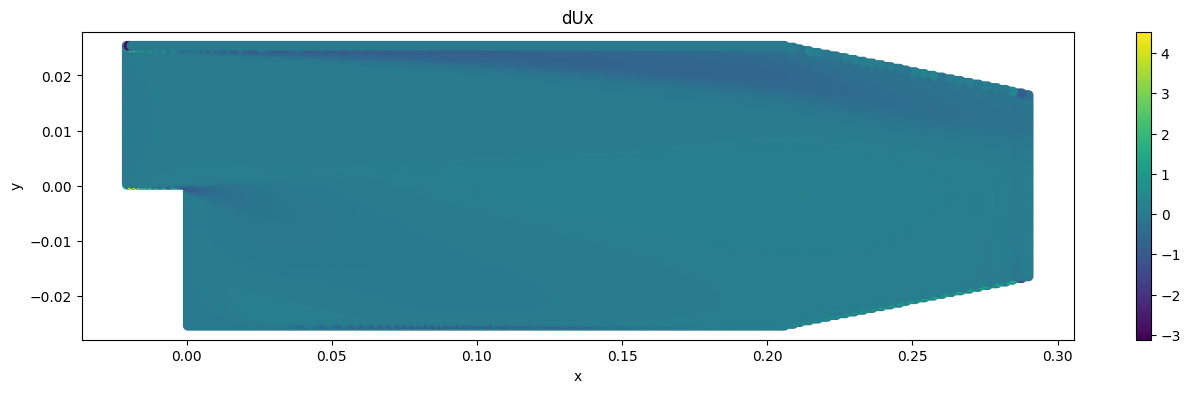

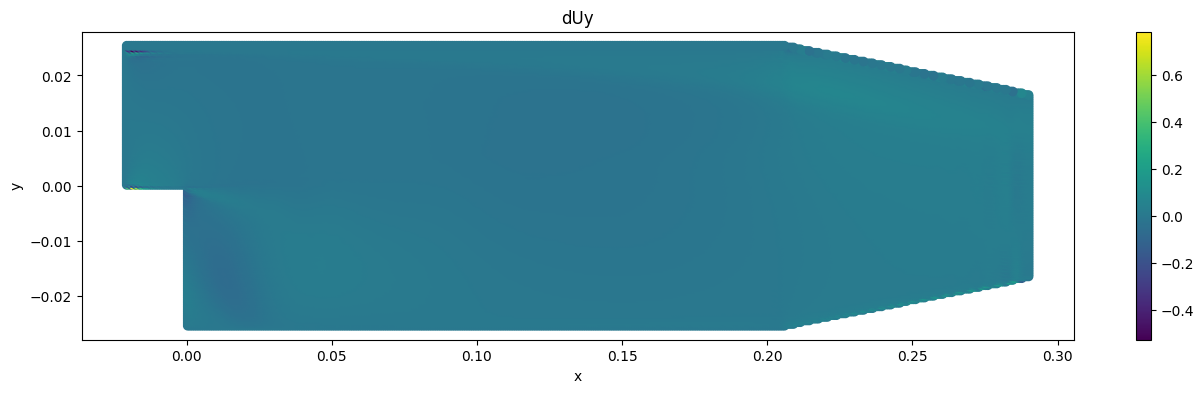

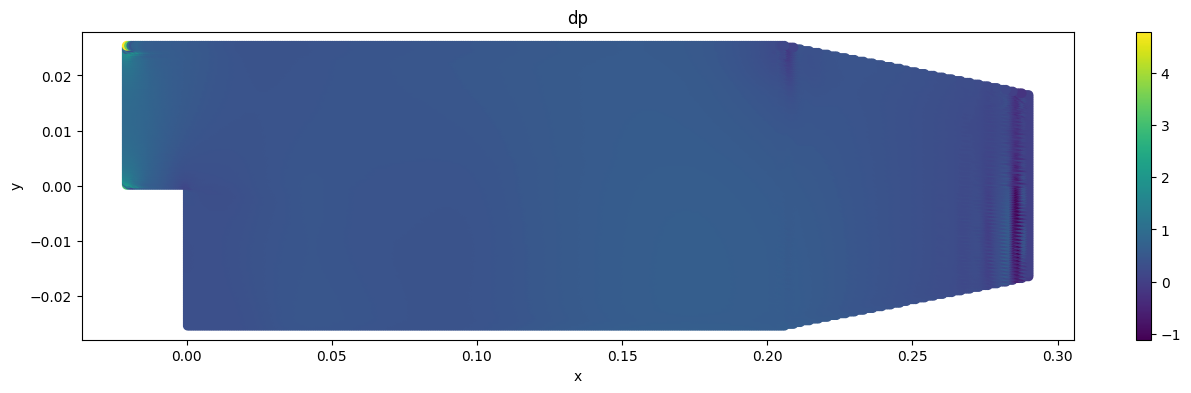

In [12]:
plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUx"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUx")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUy"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dp"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dp")
plt.show()

## Treino de um MLP

In [28]:
# ----------------------------
# Definição do Modelo
# ----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, out_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [29]:
# ----------------------------
# Treino
# ----------------------------
# original simple one:
df = pd.read_parquet(PATH_DATA / "dataset_full_pitzDaily.parquet")

feat_cols = ["x", "y", "Ux", "Uy", "p", "log_epsilon", "k", "log_nut"]

# this one with grads:
# df = pd.read_parquet("dataset_pitzDaily_with_grads.parquet")
# feat_cols = ["x", "y", "Ux", "Uy", "p", "dUx_dx", "dUx_dy", "dUy_dx", "dUy_dy", "Re"]

# this one with vorticity:
# df = pd.read_parquet(PATH_DATA / "dataset_pitzDaily_with_vorticity.parquet")
# feat_cols = [
# "x","y","Ux","Uy","p",
# "Um","wz",
# "dUx_dx","dUx_dy","dUy_dx","dUy_dy",
# "Re"
# ]

targ_cols = ["dUx", "dUy", "dp"]

X = df[feat_cols].values.astype(np.float32)
Y = df[targ_cols].values.astype(np.float32)

# guardamos indices pra puxar coarse/fine depois com consistência
idx_all = np.arange(len(df))

# 1) split: train vs temp (val+test)
X_tr, X_tmp, Y_tr, Y_tmp, idx_tr, idx_tmp = train_test_split(
    X, Y, idx_all, test_size=0.30, random_state=42, shuffle=True
)

# 2) split: val vs test (metade/metade do tmp => 15%/15%)
X_va, X_te, Y_va, Y_te, idx_va, idx_te = train_test_split(
    X_tmp, Y_tmp, idx_tmp, test_size=0.50, random_state=42, shuffle=True
)

# normalização (fit só no treino)
sx = StandardScaler().fit(X_tr)
sy = StandardScaler().fit(Y_tr)

X_tr_s = sx.transform(X_tr).astype(np.float32)
X_va_s = sx.transform(X_va).astype(np.float32)
X_te_s = sx.transform(X_te).astype(np.float32)

Y_tr_s = sy.transform(Y_tr).astype(np.float32)
Y_va_s = sy.transform(Y_va).astype(np.float32)
Y_te_s = sy.transform(Y_te).astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr_t = torch.tensor(X_tr_s, device=device)
Ytr_t = torch.tensor(Y_tr_s, device=device)
Xva_t = torch.tensor(X_va_s, device=device)
Yva_t = torch.tensor(Y_va_s, device=device)

model = MLP(in_dim=X.shape[1], hidden=64, out_dim=3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# treino + early stopping na VAL
best_val = float("inf")
patience = 12
bad = 0
max_epochs = 3000

for epoch in range(1, max_epochs + 1):
    model.train()
    opt.zero_grad()
    pred = model(Xtr_t)
    loss = loss_fn(pred, Ytr_t)
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t), Yva_t).item()

    if val_loss < best_val:
        best_val = val_loss
        bad = 0
        torch.save(model.state_dict(), PATH_MODEL / "mlp_k_eps_dU.pt")
    else:
        bad += 1

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train={loss.item():.6e} | val={val_loss:.6e}")

    if bad >= patience:
        print("Early stopping (val não melhorou).")
        break

# salvar scalers
joblib.dump(sx, PATH_OUT / "scaler_X.pkl")
joblib.dump(sy, PATH_OUT / "scaler_Y.pkl")
print("Salvo: mlp_dU.pt, scaler_X.pkl, scaler_Y.pkl")

Epoch 001 | train=1.047913e+00 | val=1.047976e+00
Epoch 300 | train=1.993471e-01 | val=2.045143e-01
Epoch 600 | train=1.282821e-01 | val=1.456968e-01
Epoch 900 | train=9.782309e-02 | val=1.237559e-01
Early stopping (val não melhorou).
Salvo: mlp_dU.pt, scaler_X.pkl, scaler_Y.pkl


### Métricas

In [30]:
# ----------------------------
# Métricas
# ----------------------------
def mae_uv(u1, v1, u2, v2) -> float:
    """MAE vetorial médio: E[ sqrt((du)^2 + (dv)^2) ]"""
    return float(np.mean(np.sqrt((u1 - u2) ** 2 + (v1 - v2) ** 2)))

def mae_p(p1, p2):
    return float(np.mean(np.abs(p1 - p2)))

def rer(
    u_corr, v_corr,
    u_c, v_c,
    u_f, v_f
):
    num = np.sqrt(
        np.sum(
            (u_corr-u_f)**2 +
            (v_corr-v_f)**2
        )
    )

    den = np.sqrt(
        np.sum(
            (u_c-u_f)**2 +
            (v_c-v_f)**2
        )
    )

    if den < 1e-12:
        return np.nan

    return float(1.0 - num/den)

def rer_p(
    p_corr,
    p_c,
    p_f
):
    num = np.linalg.norm(p_corr-p_f)
    den = np.linalg.norm(p_c-p_f)

    if den < 1e-12:
        return np.nan

    return float(1.0 - num/den)

def rmse_uv(
    u1, v1,
    u2, v2
):
    return float(
        np.sqrt(
            np.mean(
                (u1-u2)**2 +
                (v1-v2)**2
            )
        )
    )

def rmse_p(
    p1,
    p2
):
    return float(
        np.sqrt(
            np.mean(
                (p1-p2)**2
            )
        )
    )

In [31]:
# ----------------------------
# Avaliação no TESTE
# ----------------------------
model.load_state_dict(torch.load(PATH_MODEL / "mlp_k_eps_dU.pt", map_location=device))
model.eval()

Xte_t = torch.tensor(X_te_s, device=device)
with torch.no_grad():
    d_pred_s = model(Xte_t).cpu().numpy()

d_pred = sy.inverse_transform(d_pred_s).astype(np.float64)

# campos coarse/fine do TESTE (usando idx_te)
u_c = df.loc[idx_te, "Ux"].values.astype(np.float64)
v_c = df.loc[idx_te, "Uy"].values.astype(np.float64)
p_c = df.loc[idx_te, "p"].values.astype(np.float64)
u_f = (df.loc[idx_te, "Ux"].values + df.loc[idx_te, "dUx"].values).astype(np.float64)
v_f = (df.loc[idx_te, "Uy"].values + df.loc[idx_te, "dUy"].values).astype(np.float64)
p_f = (df.loc[idx_te, "p"].values + df.loc[idx_te, "dp"].values).astype(np.float64)

u_corr = u_c + d_pred[:, 0]
v_corr = v_c + d_pred[:, 1]
p_corr = p_c + d_pred[:, 2]

mae_base = mae_uv(u_c, v_c, u_f, v_f)
mae_corr = mae_uv(u_corr, v_corr, u_f, v_f)
mae_p_base = mae_p(p_c, p_f)
mae_p_corr = mae_p(p_corr, p_f)
rer_val = rer(u_corr, v_corr, u_c, v_c, u_f, v_f)
rer_p_val = rer_p(p_corr, p_c, p_f)
rmse_uv_base = rmse_uv(u_c, v_c, u_f, v_f)
rmse_uv_corr = rmse_uv(u_corr, v_corr, u_f, v_f)
rmse_p_base = rmse_p(p_c, p_f)
rmse_p_corr = rmse_p(p_corr, p_f)
improve_mae = 100.0 * (1.0 - mae_corr / mae_base) if mae_base > 0 else 0.0
improve_rmse = 100.0 * (1.0 - rmse_uv_corr / rmse_uv_base) if rmse_uv_base > 0 else 0.0

print("\n--- Métricas (TESTE) ---")
print(f"MAE (u,v) vetorial (coarse -> fine): {mae_base:.6f}")
print(f"MAE (p) escalar (coarse -> fine): {mae_p_base:.6f}")
print(f"RMSE (u,v) vetorial (coarse -> fine): {rmse_uv_base:.6f}")
print(f"RMSE (p) escalar (coarse -> fine): {rmse_p_base:.6f}")
print(f"MAE (u,v) vetorial (corrigido -> fine): {mae_corr:.6f}")
print(f"MAE (p) escalar (corrigido -> fine): {mae_p_corr:.6f}")
print(f"RMSE (u,v) vetorial (corrigido -> fine): {rmse_uv_corr:.6f}")
print(f"RMSE (p) escalar (corrigido -> fine): {rmse_p_corr:.6f}")
print(f"RER (u,v): {rer_val:.4f}")
print(f"RER (p): {rer_p_val:.4f}")
print(f"Melhora (u,v) (MAE): {improve_mae:.2f}%")
print(f"Melhora (u,v) (RMSE): {improve_rmse:.2f}%")


metrics = {
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    "n_total": int(len(df)),
    "n_train": int(len(idx_tr)),
    "n_val": int(len(idx_va)),
    "n_test": int(len(idx_te)),
    "mae_base_test": mae_base,
    "mae_corr_test": mae_corr,
    "mae_p_base_test": mae_p_base,
    "mae_p_corr_test": mae_p_corr,
    "rmse_uv_base_test": rmse_uv_base,
    "rmse_uv_corr_test": rmse_uv_corr,
    "rmse_p_base_test": rmse_p_base,
    "rmse_p_corr_test": rmse_p_corr,
    "rer_uv_test": rer_val,
    "rer_p_test": rer_p_val,
    "improve_uv_mae_pct_test": improve_mae,
    "improve_uv_rmse_pct_test": improve_rmse,
    "best_val_loss_scaled": best_val,
    "device": str(device),
}

with open(PATH_OUT / "metrics_test.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Salvo: metrics_test.json")

# salvar previsões do TESTE (pra plotar só o teste)
out = df.loc[idx_te, ["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()
out["dUx_pred"] = d_pred[:, 0]
out["dUy_pred"] = d_pred[:, 1]
out["dp_pred"] = d_pred[:, 2]
out["Ux_f"] = out["Ux"] + out["dUx"]
out["Uy_f"] = out["Uy"] + out["dUy"]
out["Ux_corr"] = out["Ux"] + out["dUx_pred"]
out["Uy_corr"] = out["Uy"] + out["dUy_pred"]
out["p_corr"] = out["p"] + out["dp_pred"]
out.to_parquet(PATH_OUT / "predictions_test.parquet", index=False)
print("Salvo: predictions_test.parquet (somente TESTE)")


--- Métricas (TESTE) ---
MAE (u,v) vetorial (coarse -> fine): 0.118167
MAE (p) escalar (coarse -> fine): 0.463090
RMSE (u,v) vetorial (coarse -> fine): 0.187859
RMSE (p) escalar (coarse -> fine): 0.481019
MAE (u,v) vetorial (corrigido -> fine): 0.016647
MAE (p) escalar (corrigido -> fine): 0.016647
RMSE (u,v) vetorial (corrigido -> fine): 0.056270
RMSE (p) escalar (corrigido -> fine): 0.059737
RER (u,v): 0.7005
RER (p): 0.8758
Melhora (u,v) (MAE): 85.91%
Melhora (u,v) (RMSE): 70.05%
Salvo: metrics_test.json
Salvo: predictions_test.parquet (somente TESTE)


In [32]:
# ----------------------------
# Predição no DOMÍNIO TODO
# ----------------------------
X_all = df[feat_cols].values.astype(np.float32)   # use a mesma lista FEATURES do treino
X_all_s = sx.transform(X_all)

X_all_t = torch.tensor(X_all_s, device=device)

with torch.no_grad():
    d_all_pred_s = model(X_all_t).cpu().numpy()

d_all_pred = sy.inverse_transform(d_all_pred_s).astype(np.float64)

pred_all = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

pred_all["Ux_f"] = pred_all["Ux"] + pred_all["dUx"]
pred_all["Uy_f"] = pred_all["Uy"] + pred_all["dUy"]
pred_all["p_f"]  = pred_all["p"]  + pred_all["dp"]

pred_all["dUx_pred"] = d_all_pred[:, 0]
pred_all["dUy_pred"] = d_all_pred[:, 1]
pred_all["dp_pred"]  = d_all_pred[:, 2]

pred_all["Ux_corr"] = pred_all["Ux"] + pred_all["dUx_pred"]
pred_all["Uy_corr"] = pred_all["Uy"] + pred_all["dUy_pred"]
pred_all["p_corr"]  = pred_all["p"]  + pred_all["dp_pred"]

pred_all.to_parquet(PATH_OUT / "predictions_all.parquet", index=False)
print("Salvo: predictions_all.parquet")

Salvo: predictions_all.parquet


### Plots

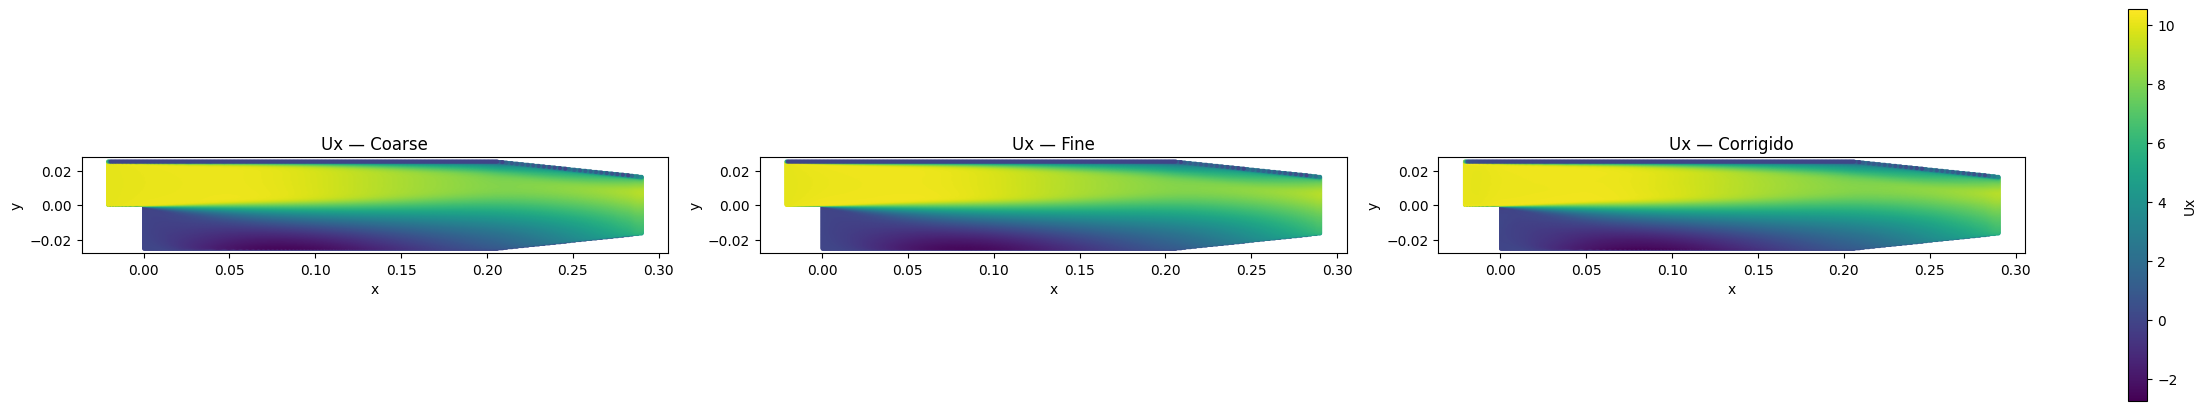

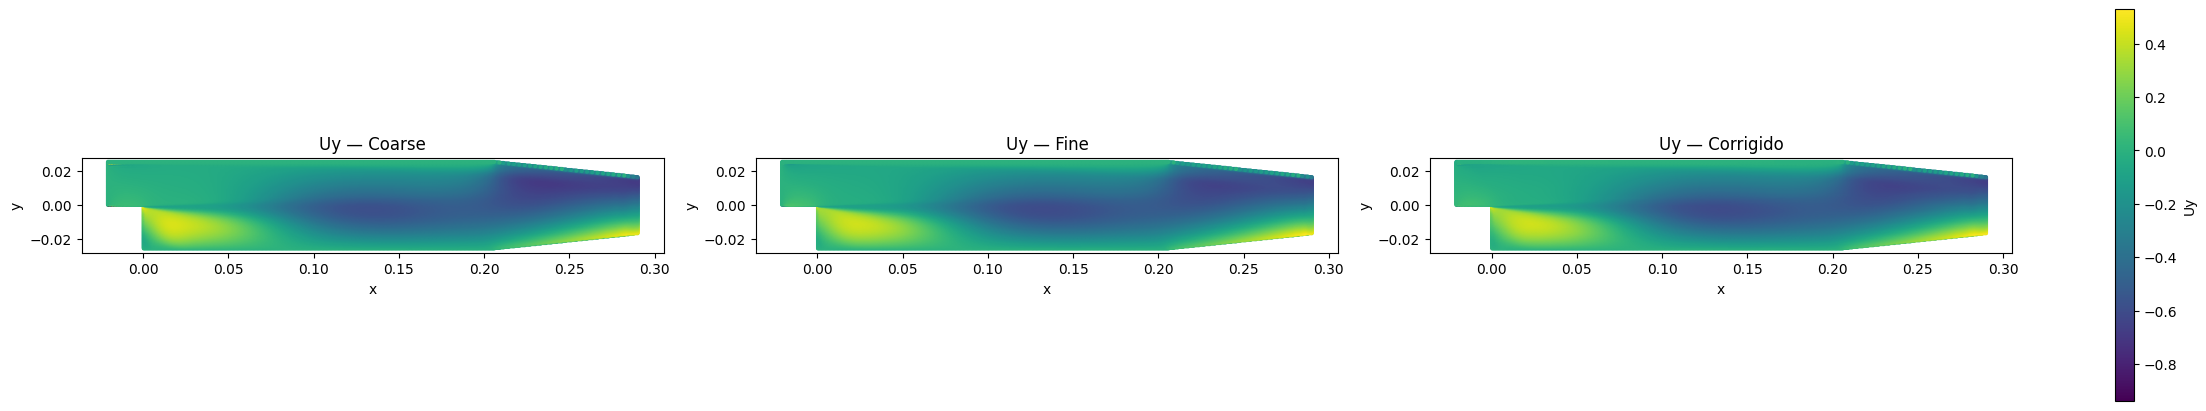

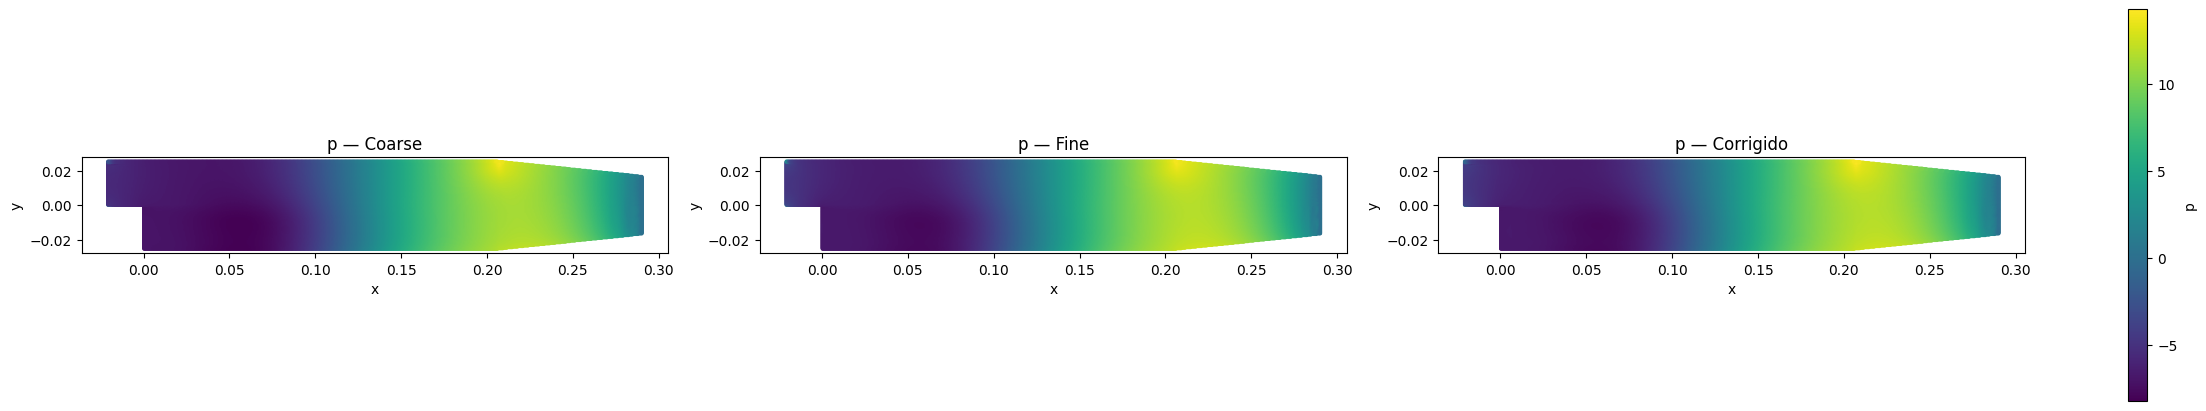

In [17]:
def plot_field_compare(df_plot, field_c, field_f, field_corr, title, cmap="viridis"):
    x = df_plot["x"].values
    y = df_plot["y"].values

    vals = np.concatenate([
        df_plot[field_c].values,
        df_plot[field_f].values,
        df_plot[field_corr].values
    ])

    vmin, vmax = np.nanmin(vals), np.nanmax(vals)

    fig, axes = plt.subplots(1, 3, figsize=(22, 4), constrained_layout=True)

    titles = ["Coarse", "Fine", "Corrigido"]
    fields = [field_c, field_f, field_corr]

    for ax, f, t in zip(axes, fields, titles):
        sc = ax.scatter(
            x, y,
            c=df_plot[f].values,
            s=4,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(f"{title} — {t}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")

    fig.colorbar(sc, ax=axes, label=title)
    plt.show()


plot_field_compare(pred_all, "Ux", "Ux_f", "Ux_corr", "Ux")
plot_field_compare(pred_all, "Uy", "Uy_f", "Uy_corr", "Uy")
plot_field_compare(pred_all, "p", "p_f", "p_corr", "p")

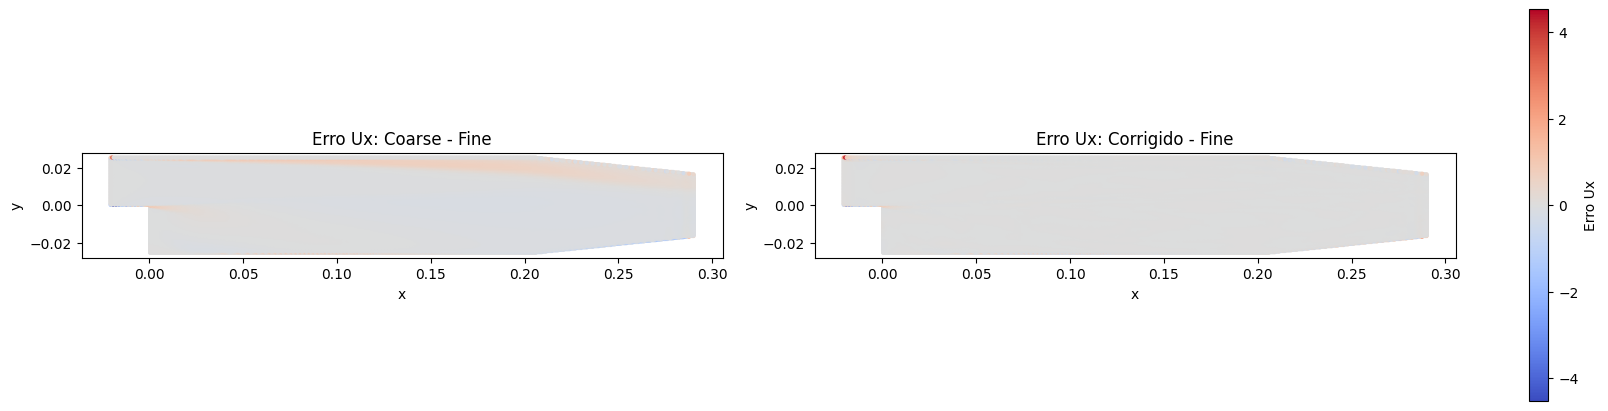

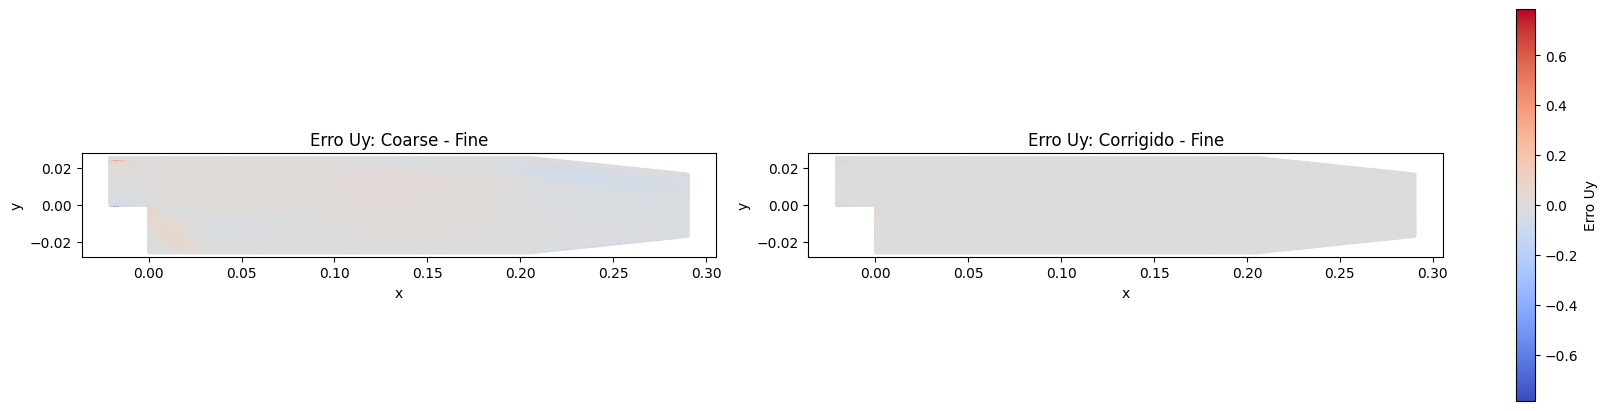

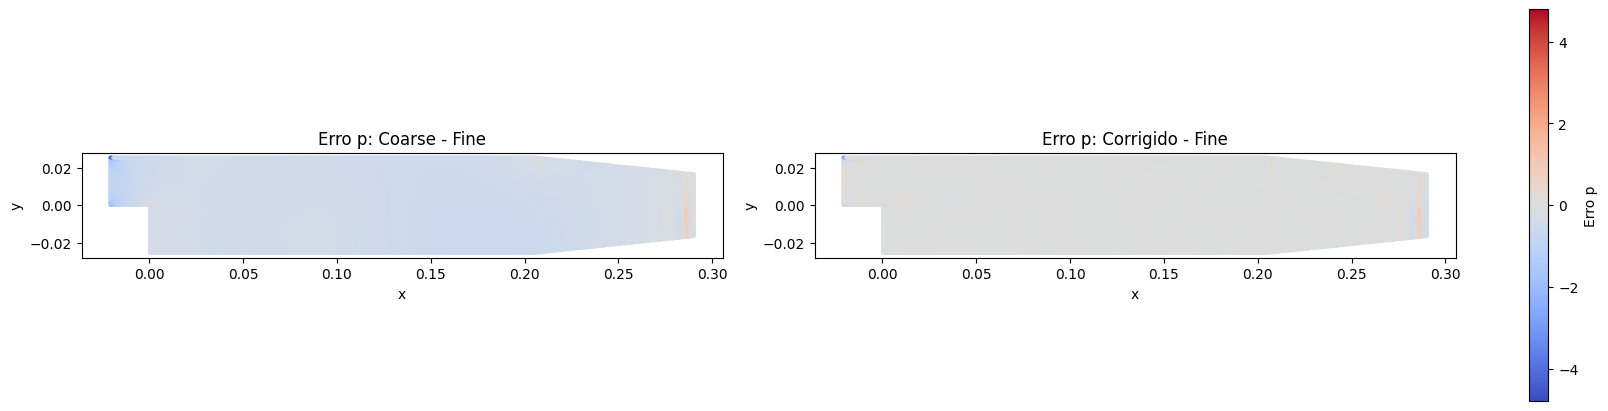

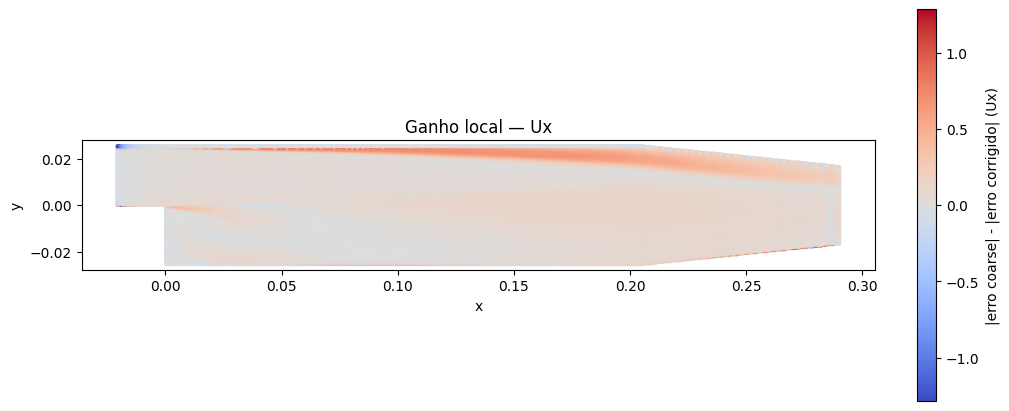

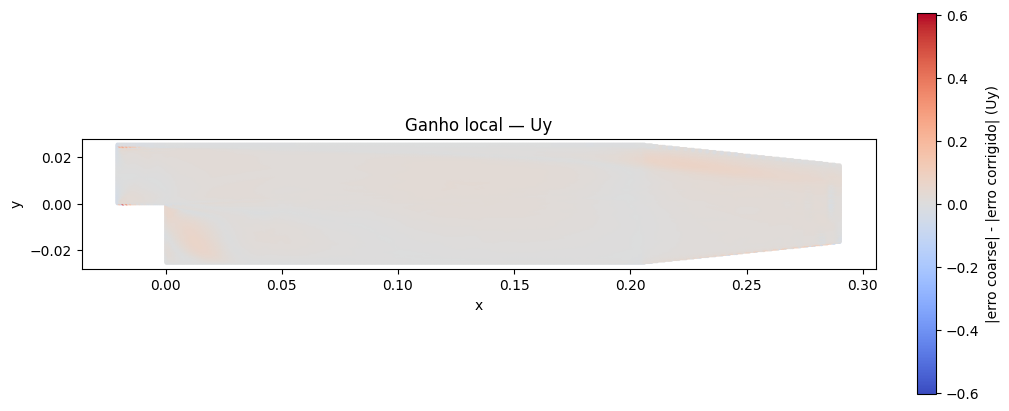

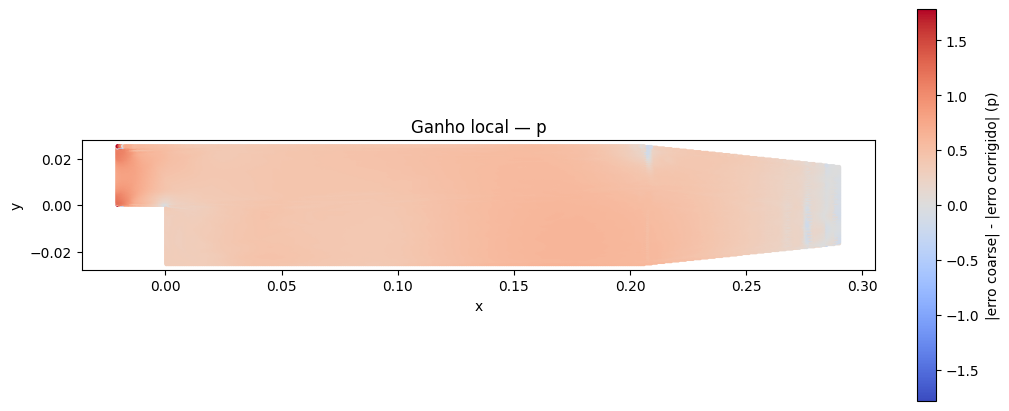

In [18]:
# -------------------------------------------------
# 1. Mapas de erro: Coarse - Fine vs Corrigido - Fine
# -------------------------------------------------

def plot_error_compare(df_plot, field_c, field_f, field_corr, label, save_path=None):
    x = df_plot["x"].values
    y = df_plot["y"].values

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    vmax = max(
        np.nanmax(np.abs(err_base)),
        np.nanmax(np.abs(err_corr))
    )
    vmin = -vmax

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 4),
        constrained_layout=True
    )

    sc0 = axes[0].scatter(
        x, y,
        c=err_base,
        s=4,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title(f"Erro {label}: Coarse - Fine")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")

    sc1 = axes[1].scatter(
        x, y,
        c=err_corr,
        s=4,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title(f"Erro {label}: Corrigido - Fine")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].set_aspect("equal")

    fig.colorbar(sc1, ax=axes, label=f"Erro {label}")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# 2. Ganho local: |erro coarse| - |erro corrigido|
# -------------------------------------------------

def plot_local_gain(df_plot, field_c, field_f, field_corr, label, save_path=None):
    x = df_plot["x"].values
    y = df_plot["y"].values

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    gain = np.abs(err_base) - np.abs(err_corr)

    vmax = np.nanmax(np.abs(gain))
    vmin = -vmax

    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    sc = ax.scatter(
        x, y,
        c=gain,
        s=4,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Ganho local — {label}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"|erro coarse| - |erro corrigido| ({label})")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# 3. Executar para Ux, Uy e p
# -------------------------------------------------

plot_error_compare(
    pred_all,
    field_c="Ux",
    field_f="Ux_f",
    field_corr="Ux_corr",
    label="Ux",
    save_path=PATH_OUT / "erro_Ux_coarse_vs_corrigido.png"
)

plot_error_compare(
    pred_all,
    field_c="Uy",
    field_f="Uy_f",
    field_corr="Uy_corr",
    label="Uy",
    save_path=PATH_OUT / "erro_Uy_coarse_vs_corrigido.png"
)

plot_error_compare(
    pred_all,
    field_c="p",
    field_f="p_f",
    field_corr="p_corr",
    label="p",
    save_path=PATH_OUT / "erro_p_coarse_vs_corrigido.png"
)

plot_local_gain(
    pred_all,
    field_c="Ux",
    field_f="Ux_f",
    field_corr="Ux_corr",
    label="Ux",
    save_path=PATH_OUT / "ganho_local_Ux.png"
)

plot_local_gain(
    pred_all,
    field_c="Uy",
    field_f="Uy_f",
    field_corr="Uy_corr",
    label="Uy",
    save_path=PATH_OUT / "ganho_local_Uy.png"
)

plot_local_gain(
    pred_all,
    field_c="p",
    field_f="p_f",
    field_corr="p_corr",
    label="p",
    save_path=PATH_OUT / "ganho_local_p.png"
)

In [19]:
def plot_error_histogram(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    bins=100,
    save_path=None
):
    err_coarse = np.abs(
        df_plot[field_c].values -
        df_plot[field_f].values
    )

    err_corr = np.abs(
        df_plot[field_corr].values -
        df_plot[field_f].values
    )

    fig, ax = plt.subplots(
        figsize=(8, 5),
        constrained_layout=True
    )

    ax.hist(
        err_coarse,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Coarse",
        edgecolor="black"
    )

    ax.hist(
        err_corr,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Corrigido",
        edgecolor="black"
    )

    ax.set_xlabel(f"|Erro| ({label})")
    ax.set_ylabel("Densidade")

    ax.set_title(
        f"Distribuição do erro absoluto - {label}"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def plot_scatter_prediction(
    df_plot,
    field_f,
    field_corr,
    label,
    sample_frac=1.0,
    save_path=None
):
    df_tmp = df_plot

    if sample_frac < 1.0:
        df_tmp = df_plot.sample(
            frac=sample_frac,
            random_state=42
        )

    x = df_tmp[field_f].values
    y = df_tmp[field_corr].values

    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())

    fig, ax = plt.subplots(
        figsize=(6, 6),
        constrained_layout=True
    )

    ax.scatter(
        x,
        y,
        s=3,
        alpha=0.3
    )

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        'r--',
        linewidth=2,
        label="y=x"
    )

    ax.set_xlabel(f"{label} Fine")
    ax.set_ylabel(f"{label} Corrigido")

    ax.set_title(
        f"{label}: Predito vs Referência"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    ax.set_aspect("equal")

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

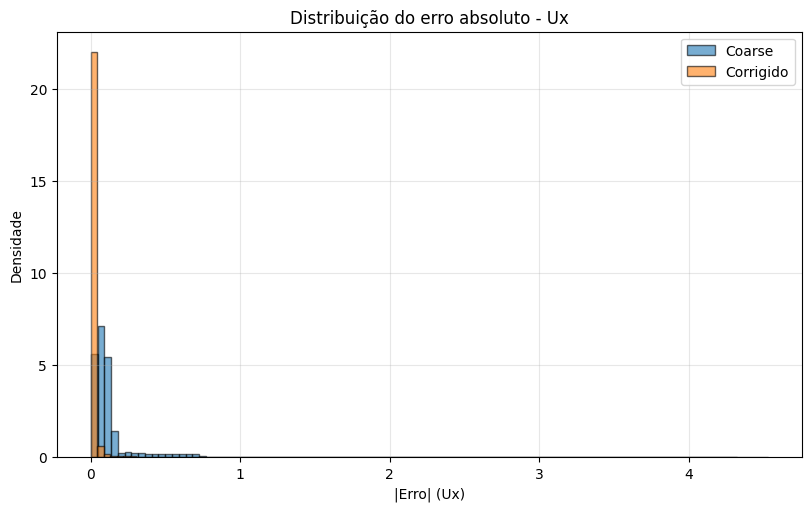

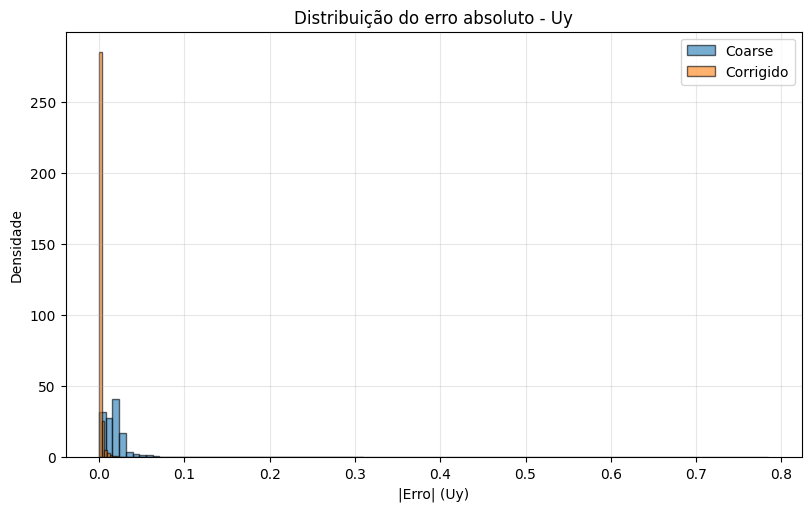

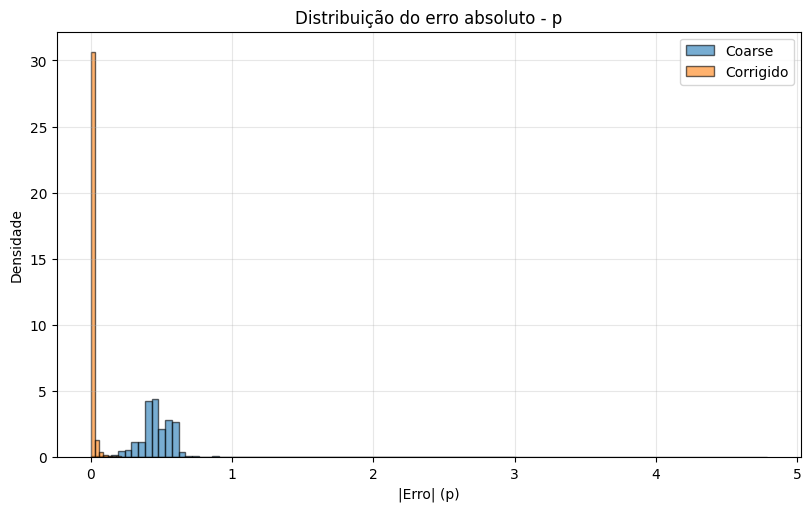

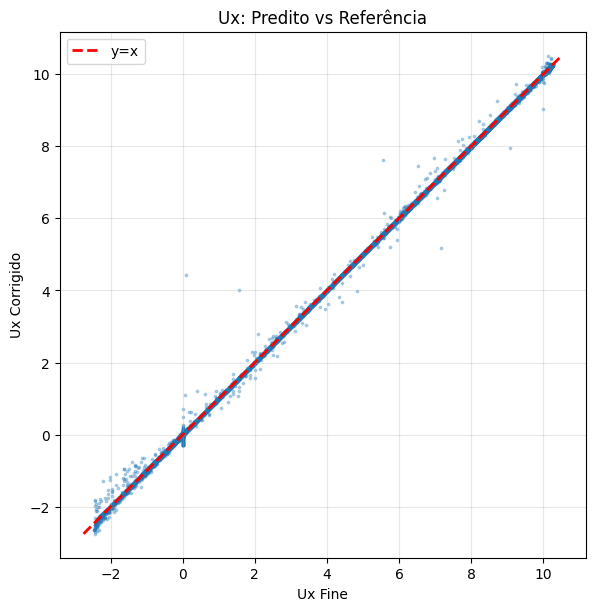

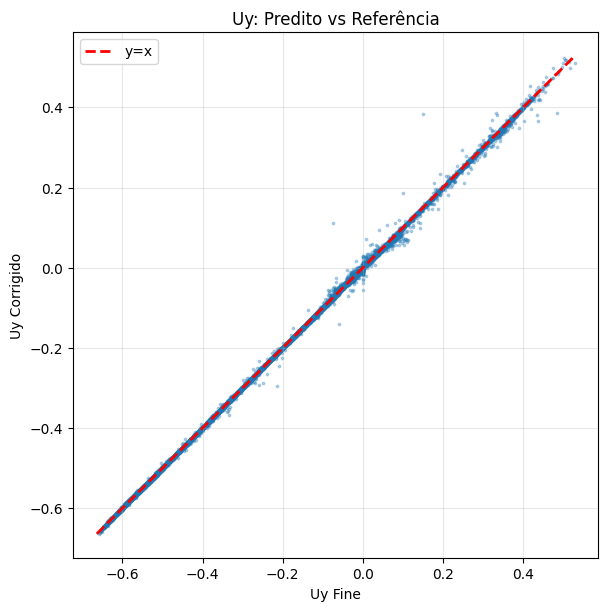

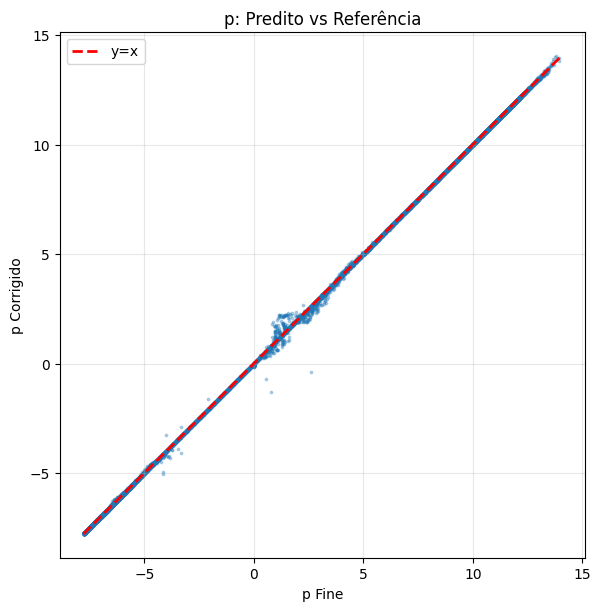

In [20]:
plot_error_histogram(
    pred_all,
    "Ux",
    "Ux_f",
    "Ux_corr",
    "Ux",
    save_path=PATH_OUT / "hist_error_Ux.png"
)

plot_error_histogram(
    pred_all,
    "Uy",
    "Uy_f",
    "Uy_corr",
    "Uy",
    save_path=PATH_OUT / "hist_error_Uy.png"
)

plot_error_histogram(
    pred_all,
    "p",
    "p_f",
    "p_corr",
    "p",
    save_path=PATH_OUT / "hist_error_p.png"
)

plot_scatter_prediction(
    pred_all,
    "Ux_f",
    "Ux_corr",
    "Ux",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Ux.png"
)

plot_scatter_prediction(
    pred_all,
    "Uy_f",
    "Uy_corr",
    "Uy",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Uy.png"
)

plot_scatter_prediction(
    pred_all,
    "p_f",
    "p_corr",
    "p",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_p.png"
)

In [21]:
from sklearn.metrics import r2_score

print("R2 Ux :", r2_score(pred_all["Ux_f"], pred_all["Ux_corr"]))
print("R2 Uy :", r2_score(pred_all["Uy_f"], pred_all["Uy_corr"]))
print("R2 p  :", r2_score(pred_all["p_f"], pred_all["p_corr"]))

R2 Ux : 0.9997814522937776
R2 Uy : 0.9996880568776061
R2 p  : 0.9999346287973105


In [22]:
def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
    num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
    den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
    return float(num / (den + 1e-12))

def l2_relative_p(p_pred, p_ref):
    num = np.linalg.norm(p_pred - p_ref)
    den = np.linalg.norm(p_ref)
    return float(num / (den + 1e-12))

l2_coarse_uv = l2_relative_uv(u_c, v_c, u_f, v_f)
l2_corr_uv   = l2_relative_uv(u_corr, v_corr, u_f, v_f)

l2_coarse_p = l2_relative_p(p_c, p_f)
l2_corr_p   = l2_relative_p(p_corr, p_f)
print(f"L2 relativo (u,v) - Coarse: {l2_coarse_uv:.6e}")
print(f"L2 relativo (u,v) - Corrigido: {l2_corr_uv:.6e}")
print(f"L2 relativo (p) - Coarse: {l2_coarse_p:.6e}")
print(f"L2 relativo (p) - Corrigido: {l2_corr_p:.6e}")

L2 relativo (u,v) - Coarse: 2.823449e-02
L2 relativo (u,v) - Corrigido: 8.462040e-03
L2 relativo (p) - Coarse: 6.379357e-02
L2 relativo (p) - Corrigido: 8.016632e-03



--- Divergência ---
L2 div(U) Coarse   : 3.563680e+01
L2 div(U) Fine     : 3.074952e+01
L2 div(U) Corrigido: 3.327493e+01
MAE div(U) Coarse   : 8.290880e+00
MAE div(U) Fine     : 6.773450e+00
MAE div(U) Corrigido: 8.462658e+00


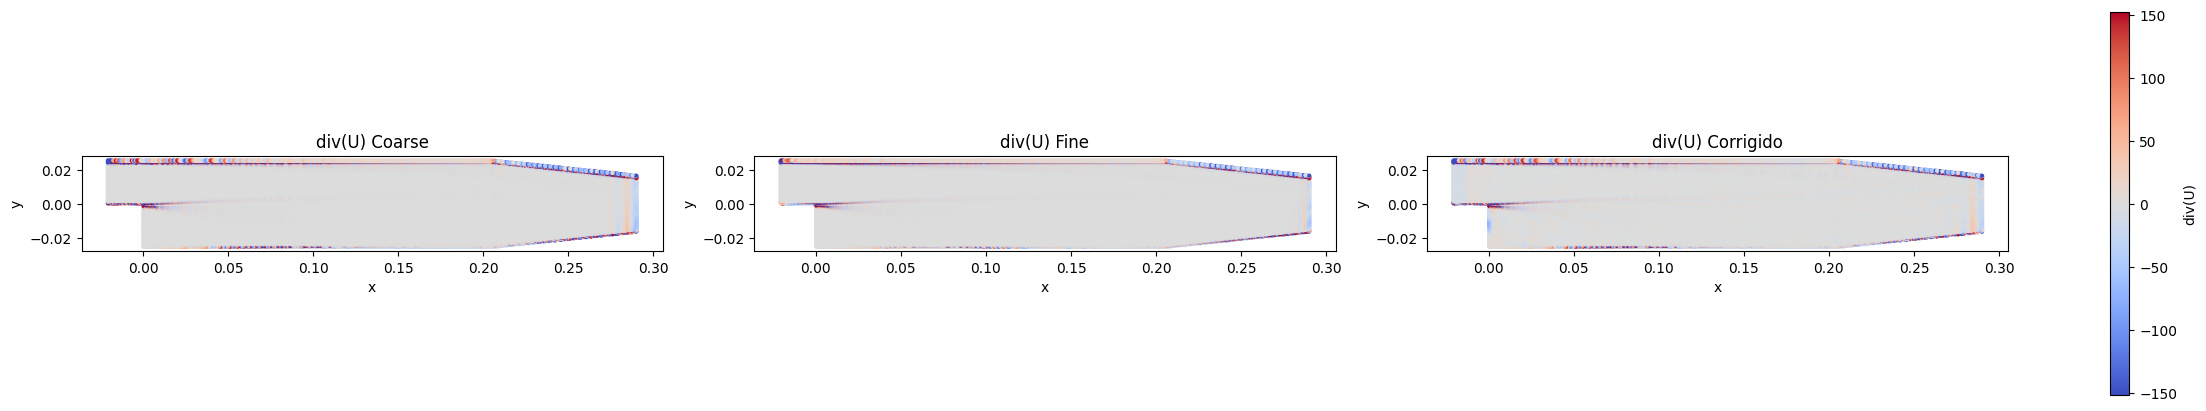

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


# -------------------------------------------------
# Gradientes locais via kNN + mínimos quadrados
# -------------------------------------------------

def local_gradients_knn(x, y, f, k_neighbors=20, eps=1e-12):
    xy = np.column_stack([x, y])

    nbrs = NearestNeighbors(
        n_neighbors=k_neighbors,
        algorithm="auto"
    ).fit(xy)

    dists, idxs = nbrs.kneighbors(xy)

    dfdx = np.zeros(len(f))
    dfdy = np.zeros(len(f))

    for i in range(len(f)):
        neigh = idxs[i]

        xi, yi = x[i], y[i]

        X = x[neigh] - xi
        Y = y[neigh] - yi
        Z = f[neigh] - f[i]

        A = np.column_stack([X, Y])

        w = 1.0 / (dists[i] + eps)
        W = np.diag(w)

        ATA = A.T @ W @ A
        ATZ = A.T @ W @ Z

        try:
            coef = np.linalg.solve(ATA, ATZ)
        except np.linalg.LinAlgError:
            coef, *_ = np.linalg.lstsq(A, Z, rcond=None)

        dfdx[i] = coef[0]
        dfdy[i] = coef[1]

    return dfdx, dfdy


# -------------------------------------------------
# Divergência
# div(U) = dUx/dx + dUy/dy
# -------------------------------------------------

def compute_divergence(df_plot, u_col, v_col, k_neighbors=20):
    x = df_plot["x"].values.astype(float)
    y = df_plot["y"].values.astype(float)

    u = df_plot[u_col].values.astype(float)
    v = df_plot[v_col].values.astype(float)

    dUdx, _ = local_gradients_knn(
        x, y, u,
        k_neighbors=k_neighbors
    )

    _, dVdy = local_gradients_knn(
        x, y, v,
        k_neighbors=k_neighbors
    )

    divU = dUdx + dVdy

    return divU


# -------------------------------------------------
# Métricas L2 da divergência
# -------------------------------------------------

def div_l2(divU):
    return float(np.sqrt(np.mean(divU**2)))


def div_mean_abs(divU):
    return float(np.mean(np.abs(divU)))


# -------------------------------------------------
# Calcular divergência para coarse, fine e corrigido
# -------------------------------------------------

pred_all["div_coarse"] = compute_divergence(
    pred_all,
    u_col="Ux",
    v_col="Uy",
    k_neighbors=20
)

pred_all["div_fine"] = compute_divergence(
    pred_all,
    u_col="Ux_f",
    v_col="Uy_f",
    k_neighbors=20
)

pred_all["div_corr"] = compute_divergence(
    pred_all,
    u_col="Ux_corr",
    v_col="Uy_corr",
    k_neighbors=20
)

print("\n--- Divergência ---")
print(f"L2 div(U) Coarse   : {div_l2(pred_all['div_coarse']):.6e}")
print(f"L2 div(U) Fine     : {div_l2(pred_all['div_fine']):.6e}")
print(f"L2 div(U) Corrigido: {div_l2(pred_all['div_corr']):.6e}")

print(f"MAE div(U) Coarse   : {div_mean_abs(pred_all['div_coarse']):.6e}")
print(f"MAE div(U) Fine     : {div_mean_abs(pred_all['div_fine']):.6e}")
print(f"MAE div(U) Corrigido: {div_mean_abs(pred_all['div_corr']):.6e}")


# -------------------------------------------------
# Plotar mapas de divergência
# -------------------------------------------------

def plot_divergence_maps(df_plot, save_path=None):
    x = df_plot["x"].values
    y = df_plot["y"].values

    fields = [
        ("div_coarse", "div(U) Coarse"),
        ("div_fine", "div(U) Fine"),
        ("div_corr", "div(U) Corrigido")
    ]

    vals = np.concatenate([
        df_plot[f].values for f, _ in fields
    ])

    vmax = np.nanpercentile(np.abs(vals), 99)
    vmin = -vmax

    fig, axes = plt.subplots(
        1, 3,
        figsize=(22, 4),
        constrained_layout=True
    )

    for ax, (field, title) in zip(axes, fields):
        sc = ax.scatter(
            x, y,
            c=df_plot[field].values,
            s=4,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")

    fig.colorbar(
        sc,
        ax=axes,
        label="div(U)"
    )

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


plot_divergence_maps(
    pred_all,
    save_path=PATH_OUT / "divergence_maps.png"
)

## Treino da PINN

In [44]:
# PINN corretor: aprende ΔU (e Δp opcional) para corrigir coarse -> aproximar fine
# Requer no parquet: x,y,Ux,Uy,p,Um,wz,dUx_dx,dUx_dy,dUy_dx,dUy_dy,Re + targets dUx,dUy (se você já tem)
# Ajuste os nomes das colunas de target conforme seu dataset.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

# -----------------------------
# 1) Dataset
# -----------------------------
FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "log_epsilon", "k", "log_nut", "Re"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)
HAS_TARGETS = True           # se quiser rodar sem supervisão, coloque False

class CFDParquet(Dataset):
    def __init__(self, df, feat_cols, target_cols=None, x_scaler=None):
        self.X = df[feat_cols].to_numpy(dtype=np.float32)
        self.has_y = target_cols is not None
        self.Y = df[target_cols].to_numpy(dtype=np.float32) if self.has_y else None

        # scaler só para features (z-score)
        if x_scaler is None:
            mu = self.X.mean(axis=0, keepdims=True)
            sd = self.X.std(axis=0, keepdims=True) + 1e-8
            self.x_mu = mu
            self.x_sd = sd
        else:
            self.x_mu, self.x_sd = x_scaler

        self.Xn = (self.X - self.x_mu) / self.x_sd

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.Xn[idx], dtype=DTYPE)
        if self.has_y:
            y = torch.tensor(self.Y[idx], dtype=DTYPE)  # <-- TARGET EM ESCALA FÍSICA
            return x, y
        return x


# -----------------------------
# 2) Modelo
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=128, depth=5, act=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, width), act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), act()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

        # init leve (ajuda tanh)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 3) Autodiff util
# -----------------------------
def grad(outputs, inputs):
    # outputs: (N,1) or (N,)
    # inputs: (N,1)
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]

def laplacian(f, x, y):
    fx = grad(f, x)
    fy = grad(f, y)
    fxx = grad(fx, x)
    fyy = grad(fy, y)
    return fxx + fyy


# -----------------------------
# 4) Resíduos físicos (2D incompressível, estacionário)
# -----------------------------
def pde_residuals(x, y, u_coarse, v_coarse, p_coarse, Re, model_out, predict_dp=True):
    """
    x, y: (N,1) leaf tensors com requires_grad=True (os mesmos do forward)
    model_out:
      se predict_dp=True: (N,3) = [dU, dV, dP]
      senão: (N,2) = [dU, dV]
    """
    if predict_dp:
        dU, dV, dP = model_out[:, [0]], model_out[:, [1]], model_out[:, [2]]
        p_hat = p_coarse + dP
    else:
        dU, dV = model_out[:, [0]], model_out[:, [1]]
        p_hat = p_coarse

    u_hat = u_coarse + dU
    v_hat = v_coarse + dV

    nu = 1.0 / (Re + 1e-12)

    # derivadas
    u_x = grad(u_hat, x); u_y = grad(u_hat, y)
    v_x = grad(v_hat, x); v_y = grad(v_hat, y)

    p_x = grad(p_hat, x); p_y = grad(p_hat, y)

    # laplacianos
    u_lap = laplacian(u_hat, x, y)
    v_lap = laplacian(v_hat, x, y)

    r_cont = u_x + v_y

    adv_u = u_hat * u_x + v_hat * u_y
    adv_v = u_hat * v_x + v_hat * v_y

    r_mom_u = adv_u + p_x - nu * u_lap
    r_mom_v = adv_v + p_y - nu * v_lap

    return r_cont, r_mom_u, r_mom_v


# -----------------------------
# 5) Treino
# -----------------------------
def train_pinn(
    parquet_path,
    batch_data=4096,
    batch_phys=4096,
    epochs_pre=50,
    epochs_phys=100,
    lr=1e-3,
    w_data=1.0,
    w_cont=1.0,
    w_mom=1.0,
    predict_dp=True,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (você pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados)
    train_ds = CFDParquet(df_tr, FEAT_COLS, TARGET_COLS if HAS_TARGETS else None)
    test_ds  = CFDParquet(df_te, FEAT_COLS, TARGET_COLS if HAS_TARGETS else None,
                      x_scaler=(train_ds.x_mu, train_ds.x_sd))


    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)
    dl_val = DataLoader(test_ds, batch_size=batch_data, shuffle=False, drop_last=False)

    in_dim = len(FEAT_COLS)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=128, depth=5, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr)

    def denorm_y(yhat_n, y_mu, y_sd):
        return yhat_n * torch.tensor(y_sd, device=yhat_n.device) + torch.tensor(y_mu, device=yhat_n.device)

    # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
    # aqui a gente precisa de x,y,Ux,Uy,p,Re em escala original pra PDE.
    feat_index = {c: i for i, c in enumerate(FEAT_COLS)}

    x_mu = torch.as_tensor(train_ds.x_mu, dtype=DTYPE, device=DEVICE)
    x_sd = torch.as_tensor(train_ds.x_sd, dtype=DTYPE, device=DEVICE)

    def unnormalize_X(Xn):
        return Xn * x_sd + x_mu
    
    # treino + early stopping na VAL
    best_val = float("inf")
    patience = 12
    bad = 0

   # ---- STAGE 1: pré-treino supervisionado
    if HAS_TARGETS and epochs_pre > 0:
        best_val = float("inf")
        bad = 0

        for ep in range(1, epochs_pre + 1):
            net.train()
            total = 0.0

            for Xn, Yn in dl_data:
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)

                opt.zero_grad(set_to_none=True)

                pred = net(Xn)
                loss = torch.mean((pred - Yn) ** 2)

                loss.backward()
                opt.step()

                total += loss.item()

            train_loss = total / len(dl_data)

            # validação real usando dl_val
            net.eval()
            val_total = 0.0

            with torch.no_grad():
                for Xv, Yv in dl_val:
                    Xv = Xv.to(DEVICE)
                    Yv = Yv.to(DEVICE)

                    pred_v = net(Xv)
                    val_loss = torch.mean((pred_v - Yv) ** 2)

                    val_total += val_loss.item()

            val_loss_epoch = val_total / len(dl_val)

            if val_loss_epoch < best_val:
                best_val = val_loss_epoch
                bad = 0
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in net.state_dict().items()
                }
            else:
                bad += 1

            if ep % 10 == 0 or ep == 1:
                print(
                    f"[PRE] ep={ep:03d} "
                    f"train={train_loss:.6e} "
                    f"val={val_loss_epoch:.6e}"
                )

            if bad >= patience:
                print("Early stopping: validação não melhorou.")
                break

        if best_state is not None:
            net.load_state_dict(best_state)


    # ---- STAGE 2: dados + física (REFATORADO / SEM detach no caminho de x,y)
    net.train()
    for ep in range(1, epochs_phys + 1):
        total = 0.0

        for batch in dl_data:
            if HAS_TARGETS:
                Xn, Yn = batch
                Yn = Yn.to(DEVICE)
            else:
                Xn = batch
                Yn = None

            Xn = Xn.to(DEVICE)

            # =========================
            # (1) Loss de dados (ΔU)
            # =========================
            pred_data = net(Xn)  # forward normal
            loss_data = torch.tensor(0.0, device=DEVICE)
            if HAS_TARGETS:
                loss_data = torch.mean((pred_data - Yn) ** 2)   # pred_data é (N,3) e Yn é (N,3)

            # ==========================================
            # (2) Loss física: x,y precisam estar no grafo
            #     então refazemos o forward com x,y requires_grad=True
            # ==========================================
            # Volta para escala física SEM detach (mantém as operações no grafo)
            # valores físicos só pra “montar” o input do PINN (não precisa de grad aqui)
            X_phys = unnormalize_X(Xn).detach() # (N, in_dim) em escala original

            # Cria x,y como tensores do grafo (folhas) para autodiff
            x = X_phys[:, [feat_index["x"]]].clone().requires_grad_(True)
            y = X_phys[:, [feat_index["y"]]].clone().requires_grad_(True)

            # Reinjeta x,y no vetor físico e renormaliza
            X_phys_mod = X_phys.clone()
            X_phys_mod[:, [feat_index["x"]]] = x
            X_phys_mod[:, [feat_index["y"]]] = y

            Xn_mod = (X_phys_mod - x_mu) / x_sd

            # Forward "physics-aware"
            pred_phys = net(Xn_mod)

            # Campos coarse (em escala física) para montar o campo corrigido
            u_c = X_phys[:, [feat_index["Ux"]]]
            v_c = X_phys[:, [feat_index["Uy"]]]
            p_c = X_phys[:, [feat_index["p"]]]
            Re  = X_phys[:, [feat_index["Re"]]]

            #print("x leaf?", x.is_leaf, "req_grad?", x.requires_grad)
            #print("y leaf?", y.is_leaf, "req_grad?", y.requires_grad)


            r_cont, r_mom_u, r_mom_v = pde_residuals(
                x=x, y=y,
                u_coarse=u_c, v_coarse=v_c, p_coarse=p_c,
                Re=Re,
                model_out=pred_phys,
                predict_dp=predict_dp
            )

            loss_cont = (r_cont ** 2).mean()
            huber = torch.nn.SmoothL1Loss(beta=1.0)
            loss_mom = huber(r_mom_u, torch.zeros_like(r_mom_u)) + huber(r_mom_v, torch.zeros_like(r_mom_v))


            loss = w_data * loss_data + w_cont * loss_cont + w_mom * loss_mom

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            total += loss.item()

        if ep % 10 == 0 or ep == 1:
            print(
                f"[PINN] ep={ep:03d} "
                f"loss={total/len(dl_data):.6e} "
                f"data={loss_data.item():.3e} cont={loss_cont.item():.3e} mom={loss_mom.item():.3e}"
            )


    return net, (train_ds.x_mu, train_ds.x_sd)

# -----------------------------
# 6) Avaliação / Métricas
# ----------------------------- 

@torch.no_grad()
def evaluate_pinn_physical(
    model, parquet_path, feat_cols, x_scaler,
    batch_size=8192, out_json=PATH_OUT / "metrics_pinn.json"
):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_path)

    Ux_c = df["Ux"].to_numpy(np.float32)
    Uy_c = df["Uy"].to_numpy(np.float32)
    p_c = df["p"].to_numpy(np.float32)

    dUx_true = df["dUx"].to_numpy(np.float32)
    dUy_true = df["dUy"].to_numpy(np.float32)
    dp_true  = df["dp"].to_numpy(np.float32)

    Ux_f = Ux_c + dUx_true
    Uy_f = Uy_c + dUy_true
    p_f  = p_c  + dp_true

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = x_scaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)

    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out = model(xb)[:, :3].detach().cpu().numpy()
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]
        
    Ux_hat = Ux_c + dUx_pred
    Uy_hat = Uy_c + dUy_pred
    p_hat  = p_c  + dp_pred

    def mae_vec(ax, ay, bx, by):
        return float(np.mean(np.sqrt((ax - bx)**2 + (ay - by)**2)))
    
    def mae_vec_pressure(p1, p2):
        return float(np.mean(np.abs(p1 - p2)))
    
    def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
        num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
        den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
        return float(num / (den + 1e-12))

    def l2_relative_p(p_pred, p_ref):
        num = np.linalg.norm(p_pred - p_ref)
        den = np.linalg.norm(p_ref)
        return float(num / (den + 1e-12))

    l2_coarse_uv = l2_relative_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    l2_corr_uv   = l2_relative_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)

    l2_coarse_p = l2_relative_p(p_c, p_f)
    l2_corr_p   = l2_relative_p(p_hat, p_f)
    

    mae_coarse = mae_vec(Ux_c, Uy_c, Ux_f, Uy_f)
    mae_p_coarse = mae_vec_pressure(p_c, p_f)
    mae_corr   = mae_vec(Ux_hat, Uy_hat, Ux_f, Uy_f)
    mae_p_corr = mae_vec_pressure(p_hat, p_f)
    mae_deltas = mae_vec(dUx_pred, dUy_pred, dUx_true, dUy_true)
    mae_deltas_p = mae_vec_pressure(dp_pred, dp_true)
    rer_uv = 1.0 - (mae_corr / (mae_coarse + 1e-12))
    melhora_pct_uv = rer_uv * 100.0
    rer_p = 1.0 - (mae_p_corr / (mae_p_coarse + 1e-12))
    melhora_pct_p = rer_p * 100.0

    metrics = {
        "mae_vec_coarse_to_fine": mae_coarse,
        "mae_vec_corrected_to_fine": mae_corr,
        "mae_vec_deltas_pred_vs_true": mae_deltas,
        "mae_vec_pressure_coarse_to_fine": mae_p_coarse,
        "mae_vec_pressure_corrected_to_fine": mae_p_corr,
        "mae_vec_pressure_deltas_pred_vs_true": mae_deltas_p,
        "l2_rel_uv_coarse": l2_coarse_uv,
        "l2_rel_uv_corrected": l2_corr_uv,
        "l2_rel_p_coarse": l2_coarse_p,
        "l2_rel_p_corrected": l2_corr_p,
        "RER (u,v)": float(rer_uv),
        "RER (p)": float(rer_p),
        "melhora_MAE_pct": float(melhora_pct_uv),
        "melhora_MAE_pct_pressure": float(melhora_pct_p),
        "N": int(len(df)),
    }

    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n--- Métricas (PINN) ---")
    print(f"MAE vetorial (coarse -> fine):     {mae_coarse:.6f}")
    print(f"MAE pressão (coarse -> fine):      {mae_p_coarse:.6f}")
    print(f"MAE vetorial (corrigido -> fine):  {mae_corr:.6f}")
    print(f"MAE pressão (corrigido -> fine):   {mae_p_corr:.6f}")
    print(f"MAE vetorial (ΔU_pred -> ΔU_true): {mae_deltas:.6f}")
    print(f"MAE pressão (Δp_pred -> Δp_true):  {mae_deltas_p:.6f}")
    print(f"RER (u,v):                         {rer_uv:.4f}")
    print(f"RER (p):                           {rer_p:.4f}")
    print(f"Melhora (u,v) (MAE):               {melhora_pct_uv:.2f}%")
    print(f"Melhora (p) (MAE):                 {melhora_pct_p:.2f}%")
    print("\n--- Métricas Físicas (PINN) ---")
    print(f"L2 relativo (u,v) - Coarse:        {l2_coarse_uv:.6e}")
    print(f"L2 relativo (u,v) - Corrigido:     {l2_corr_uv:.6e}")
    print(f"L2 relativo (p) - Coarse:          {l2_coarse_p:.6e}")
    print(f"L2 relativo (p) - Corrigido:       {l2_corr_p:.6e}")
    print(f"Salvo: {out_json}\n")

    return metrics

### Treino e métricas

In [45]:
model, xscaler = train_pinn(
    parquet_path=PATH_DATA / "dataset_full_pitzDaily.parquet",
    epochs_pre=300,
    epochs_phys=300,
    lr=1e-4,
    w_data=1.0,
    w_cont=0.01,
    w_mom=0.001,
    predict_dp=True
)

torch.save({"state_dict": model.state_dict(), "xscaler": xscaler}, PATH_MODEL / "pinn_corrector.pt")

evaluate_pinn_physical(
    model=model,
    parquet_path=PATH_DATA / "dataset_full_pitzDaily.parquet",
    feat_cols=FEAT_COLS,
    x_scaler=xscaler
)


[PRE] ep=001 train=1.024749e-01 val=6.939064e-02
[PRE] ep=010 train=8.208578e-03 val=7.815006e-03
[PRE] ep=020 train=7.195195e-03 val=6.670308e-03
[PRE] ep=030 train=6.233469e-03 val=5.828475e-03
[PRE] ep=040 train=5.515842e-03 val=5.108186e-03
[PRE] ep=050 train=4.934019e-03 val=4.649934e-03
[PRE] ep=060 train=4.789899e-03 val=4.400229e-03
[PRE] ep=070 train=4.634020e-03 val=4.214064e-03
[PRE] ep=080 train=4.487440e-03 val=4.093905e-03
[PRE] ep=090 train=4.348556e-03 val=3.978701e-03
[PRE] ep=100 train=4.306535e-03 val=3.880060e-03
[PRE] ep=110 train=4.200084e-03 val=3.792907e-03
[PRE] ep=120 train=4.110482e-03 val=3.699026e-03
[PRE] ep=130 train=4.018578e-03 val=3.620937e-03
[PRE] ep=140 train=3.867009e-03 val=3.573966e-03
[PRE] ep=150 train=3.784047e-03 val=3.498801e-03
[PRE] ep=160 train=3.894331e-03 val=3.435164e-03
[PRE] ep=170 train=3.848338e-03 val=3.383994e-03
[PRE] ep=180 train=3.769472e-03 val=3.320195e-03
[PRE] ep=190 train=3.718672e-03 val=3.286423e-03
[PRE] ep=200 train=3

{'mae_vec_coarse_to_fine': 0.11706686019897461,
 'mae_vec_corrected_to_fine': 0.02496216632425785,
 'mae_vec_deltas_pred_vs_true': 0.0249621644616127,
 'mae_vec_pressure_coarse_to_fine': 0.46318259835243225,
 'mae_vec_pressure_corrected_to_fine': 0.026827912777662277,
 'mae_vec_pressure_deltas_pred_vs_true': 0.026827912777662277,
 'l2_rel_uv_coarse': 0.02816455438733101,
 'l2_rel_uv_corrected': 0.010969378985464573,
 'l2_rel_p_coarse': 0.06357584148645401,
 'l2_rel_p_corrected': 0.009229244664311409,
 'RER (u,v)': 0.786770002359188,
 'RER (p)': 0.9420791867547856,
 'melhora_MAE_pct': 78.6770002359188,
 'melhora_MAE_pct_pressure': 94.20791867547857,
 'N': 58732}

O estudo com o caso pitzDaily validou a viabilidade do pipeline de correção coarse→fine, demonstrando que modelos neurais conseguem aprender discrepâncias entre malhas RANS de diferentes fidelidades. Entretanto, por se tratar de um caso relativamente bem condicionado, os resultados devem ser interpretados como prova de conceito metodológica, motivando a aplicação em um benchmark BFS mais representativo.